# Tree Model Baseline — RF & XGBoost

> Nonlinear model checkpoint for env-innovation-prediction.  
> Uses the same v2 main panel, `lag1_3_mean` features, and 80/10/10 chronological split as the linear baseline.

**Candidates**: 6 Random Forest + 6 XGBoost  
**Selection**: lowest validation MAE  
**Interpretation**: feature importance + SHAP summary

In [1]:
# ----- Colab-safe setup (skips locally) -----
import sys, os
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    !git clone https://github.com/YOUR_REPO/env-innovation-prediction.git
    %cd env-innovation-prediction
    !pip install -q -r requirements.txt

# ----- Project root (walk up to find the repo, regardless of working dir) -----
from pathlib import Path


def _find_project_root(start: Path) -> Path:
    """Find the repo root by walking up until 3_models/scripts/model_config.py is found.

    Works whether the Jupyter working dir is the project root, 3_models/notebooks,
    or 3_models/scripts. Raises a clear error instead of silently using a wrong path.
    """
    for candidate in [start, *start.parents]:
        if (candidate / "3_models" / "scripts" / "model_config.py").exists():
            return candidate
    raise FileNotFoundError(
        f"Could not locate the project root containing 3_models/scripts starting from {start}."
    )


ROOT = _find_project_root(Path(os.getcwd()).resolve())
SCRIPTS = ROOT / "3_models" / "scripts"
if str(SCRIPTS) not in sys.path:
    sys.path.insert(0, str(SCRIPTS))
print(f"Project root: {ROOT}")
print(f"Scripts on path: {SCRIPTS}")

Project root: /Users/jiesong/Documents/GitHub/env-innovation-prediction
Scripts on path: /Users/jiesong/Documents/GitHub/env-innovation-prediction/3_models/scripts


In [2]:
# ----- Imports -----
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, Markdown, display

from model_config import (
    TREE_OUTPUT_DIR, TREE_FIGURES_DIR,
    TREE_VALIDATION_METRICS_OUTPUT, TREE_TEST_METRICS_OUTPUT,
    TREE_IMPORTANCE_OUTPUT, TREE_HISTORICAL_BASELINES_OUTPUT,
    TREE_HISTORICAL_DELTA_OUTPUT, TREE_RUN_SUMMARY_OUTPUT,
    TREE_SAMPLE_SUMMARY_OUTPUT, TREE_FIGURE_INDEX_OUTPUT,
    TREE_NESTED_COMPARISON_OUTPUT, TREE_ROBUSTNESS_SUMMARY_OUTPUT,
    TREE_PANEL_TEST_METRICS_OUTPUT,
)

sns.set_theme(style="whitegrid", context="notebook")
print(f"Outputs: {TREE_OUTPUT_DIR}")
print(f"Figures: {TREE_FIGURES_DIR}")

def show_tree_figure(name: str) -> None:
    """Display a pre-generated tree figure PNG (logic lives in the pipeline)."""
    display(Image(filename=str(TREE_FIGURES_DIR / f"{name}.png")))


Outputs: /Users/jiesong/Documents/GitHub/env-innovation-prediction/3_models/outputs/tree
Figures: /Users/jiesong/Documents/GitHub/env-innovation-prediction/4_analysis/figures/tree_modeling


## 1. Run Summary

In [3]:
if TREE_RUN_SUMMARY_OUTPUT.exists():
    display(Markdown(TREE_RUN_SUMMARY_OUTPUT.read_text()))
else:
    print(f"Summary not found at {TREE_RUN_SUMMARY_OUTPUT}. Run `python 3_models/scripts/run_modeling.py --tree` first.")

# Tree Model Run Summary

Best validation model: `xgb_n500_d6`

## Chronological Split

- Train years: 1999-2018
- Validation years: 2019-2020
- Test years: 2021-2023

## Best Validation Metrics

| panel_id | panel_label | panel_role | comparison_group | feature_set_role | target_column | lag_suffix | model | split | train_year_start | train_year_end | validation_year_start | validation_year_end | n_train | n_validation | mae | rmse | oos_r2_vs_train_mean | spearman | comparison_scope | panel_rows | panel_countries | feature_columns | train_rows | validation_rows | train_countries | validation_countries |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| main_tree | Main v2 — tree models | main_tree | tree | primary_specification | env_patent_share_inventions | lag1_3_mean | xgb_n500_d6 | validation | 1999 | 2018 | 2019 | 2020 | 2073 | 227 | 0.254964066978165 | 0.8458281844850039 | 0.9328665470985492 | 0.7831014065238291 | own_sample_not_direct_ranking | 2612 | 174 | 8 | 2073 | 227 | 171 | 130 |

## Final Test Metrics

| panel_id | panel_label | panel_role | comparison_group | feature_set_role | target_column | lag_suffix | model | split | n_train_validation | n_test | oos_r2_baseline_mean | mae | rmse | oos_r2_vs_train_mean | spearman | comparison_scope | panel_rows | panel_countries | feature_columns | train_validation_rows | test_rows | train_validation_countries | test_countries | train_year_start | train_year_end | validation_year_start | validation_year_end | test_year_start | test_year_end |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| main_tree | Main v2 — tree models | main_tree | tree | primary_specification | env_patent_share_inventions | lag1_3_mean | xgb_n500_d6 | test | 2300 | 312 | 0.9473702586495418 | 0.46481936435462545 | 1.893446787879205 | 0.7905004238042527 | 0.8314313777459391 | own_sample_not_direct_ranking | 2612 | 174 | 8 | 2300 | 312 | 174 | 128 | 1999 | 2018 | 2019 | 2020 | 2021 | 2023 |

The selected model is chosen by validation MAE. The final test block is the latest
contiguous period and is not used for model selection.

## Historical Baseline Comparison

| model | split | prediction_rule | n_test | uses_test_labels | mae | rmse | oos_r2_vs_train_mean | spearman |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| country_last_pretest_holdconstant | test | country latest observed train+validation target held constant | 312 | False | 0.3118602401339744 | 1.5534402797740023 | 0.8589847558580282 | 0.9396713041005564 |
| xgb_n500_d6 | test | selected_model | 312 | False | 0.46481936435462545 | 1.893446787879205 | 0.7905004238042527 | 0.8314313777459391 |
| country_train_validation_mean | test | country mean target through validation period, global fallback | 312 | False | 0.6794167908354009 | 3.313285418784909 | 0.3585029874515381 | 0.9410278131087497 |
| global_train_validation_mean | test | constant mean of train+validation targets | 312 | False | 1.543124173267155 | 4.136773023191855 | -7.483574755440259e-07 |  |

## Historical Baseline Delta Summary

| selected_model | baseline_model | baseline_prediction_rule | selected_mae | baseline_mae | delta_mae_selected_minus_baseline | selected_rmse | baseline_rmse | delta_rmse_selected_minus_baseline | selected_beats_baseline | professor_interpretation |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| xgb_n500_d6 | country_last_pretest_holdconstant | country latest observed train+validation target held constant | 0.46481936435462545 | 0.3118602401339744 | 0.15295912422065105 | 1.893446787879205 | 1.5534402797740023 | 0.3400065081052026 | False | The feature-only model trails this historical baseline on test MAE; do not claim that external predictors beat national historical persistence. |
| xgb_n500_d6 | country_train_validation_mean | country mean target through validation period, global fallback | 0.46481936435462545 | 0.6794167908354009 | -0.2145974264807754 | 1.893446787879205 | 3.313285418784909 | -1.419838630905704 | True | The feature-only model beats this historical baseline on test MAE; still interpret the result as predictive association, not causality. |
| xgb_n500_d6 | global_train_validation_mean | constant mean of train+validation targets | 0.46481936435462545 | 1.543124173267155 | -1.0783048089125296 | 1.893446787879205 | 4.136773023191855 | -2.2433262353126504 | True | The feature-only model beats this historical baseline on test MAE; still interpret the result as predictive association, not causality. |

## Mechanism Submodel Own-Sample Comparison (Tree)

Own-sample diagnostics only; panels have different country/year coverage and are not a direct ranking against the main model.

| panel_id | panel_label | model | mae | rmse | oos_r2_vs_train_mean | spearman |
| --- | --- | --- | --- | --- | --- | --- |
| main | Main v2 model | xgb_n500_d6 | 0.46481936435462545 | 1.893446787879205 | 0.7905004238042527 | 0.8314313777459391 |
| suba | Submodel A: RISE and high-tech exports | rf_n500 | 1.4456868018987485 | 4.006069329673235 | 0.2795249560880132 | 0.6820421333628401 |
| subb | Submodel B: R&D, co-invention, and tax | xgb_n500_d6 | 0.8361898255488986 | 3.120074657864808 | 0.47939386604242085 | 0.7011332322749118 |
| subc | Submodel C: OECD EPS | xgb_n500_d3 | 3.5854998933010007 | 5.387111192650645 | -0.02774857901288308 | 0.12052529679633525 |

## Same-Sample Nested Submodel Tests (Tree)

Each comparison uses the same country-year rows for main-controls and main-plus-submodel. A negative delta means the submodel predictors help.

| comparison_group | rows | countries | baseline_test_mae | augmented_test_mae | delta_test_mae_augmented_minus_baseline | improves_primary_test_mae |
| --- | --- | --- | --- | --- | --- | --- |
| suba | 1012 | 124 | 0.5542627383247962 | 0.5226637285834302 | -0.03159900974136598 | True |
| subb | 2190 | 109 | 0.5743681558827206 | 0.6213761933626893 | 0.047008037479968734 | False |
| subc | 918 | 40 | 0.8854598917225002 | 0.9168952246720357 | 0.03143533294953549 | False |

## Tree Robustness Pack (lag1 timing + per-million target)

| robustness_id | target_column | lag_suffix | best_model | test_mae | best_historical_baseline_mae | delta_test_mae_selected_minus_best_history | beats_best_historical_baseline |
| --- | --- | --- | --- | --- | --- | --- | --- |
| robust_main_share_lag1 | env_patent_share_inventions | lag1 | rf_n200 | 0.5362746239650492 | 0.3118602401339744 | 0.22441438383107482 | False |
| robust_main_share_lag1_3_mean | env_patent_share_inventions | lag1_3_mean | xgb_n500_d6 | 0.46481936435462545 | 0.3118602401339744 | 0.15295912422065105 | False |
| robust_main_per_million_lag1 | env_patents_per_million | lag1 | rf_n500 | 3.8458300069327853 | 2.572789706625659 | 1.2730403003071262 | False |
| robust_main_per_million_lag1_3_mean | env_patents_per_million | lag1_3_mean | rf_n500 | 3.463190569464506 | 2.572789706625659 | 0.8904008628388471 | False |


## 2. Sample Summary

In [4]:
if TREE_SAMPLE_SUMMARY_OUTPUT.exists():
    df = pd.read_csv(TREE_SAMPLE_SUMMARY_OUTPUT)
    display(df)
else:
    print("Not yet generated.")

,panel_id,panel_label,panel_role,comparison_group,feature_set_role,target_column,lag_suffix,comparison_scope,split,year_start,year_end,years,rows,countries,target_non_missing,feature_columns,complete_feature_rows,any_feature_missing_rows
0,main_tree,Main v2 — tree models,main_tree,tree,primary_specification,env_patent_share_inventions,lag1_3_mean,own_sample_not_direct_ranking,train,1999,2018,20,2073,171,2073,8,1071,1002
1,main_tree,Main v2 — tree models,main_tree,tree,primary_specification,env_patent_share_inventions,lag1_3_mean,own_sample_not_direct_ranking,validation,2019,2020,2,227,130,227,8,158,69
2,main_tree,Main v2 — tree models,main_tree,tree,primary_specification,env_patent_share_inventions,lag1_3_mean,own_sample_not_direct_ranking,test,2021,2023,3,312,128,312,8,162,150
3,main_tree,Main v2 — tree models,main_tree,tree,primary_specification,env_patent_share_inventions,lag1_3_mean,own_sample_not_direct_ranking,all,1999,2023,25,2612,174,2612,8,1391,1221


## 3. Validation Metrics (model selection)

In [5]:
if TREE_VALIDATION_METRICS_OUTPUT.exists():
    df = pd.read_csv(TREE_VALIDATION_METRICS_OUTPUT)
    display(df.sort_values("mae").head(10))
else:
    print("Not yet generated.")

,panel_id,panel_label,panel_role,comparison_group,feature_set_role,target_column,lag_suffix,model,split,train_year_start,...,oos_r2_vs_train_mean,spearman,comparison_scope,panel_rows,panel_countries,feature_columns,train_rows,validation_rows,train_countries,validation_countries
0,main_tree,Main v2 — tree models,main_tree,tree,primary_specification,env_patent_share_inventions,lag1_3_mean,xgb_n500_d6,validation,1999,...,0.932867,0.783101,own_sample_not_direct_ranking,2612,174,8,2073,227,171,130
1,main_tree,Main v2 — tree models,main_tree,tree,primary_specification,env_patent_share_inventions,lag1_3_mean,xgb_n200_d6,validation,1999,...,0.932399,0.785578,own_sample_not_direct_ranking,2612,174,8,2073,227,171,130
2,main_tree,Main v2 — tree models,main_tree,tree,primary_specification,env_patent_share_inventions,lag1_3_mean,xgb_n100_d6,validation,1999,...,0.931392,0.771589,own_sample_not_direct_ranking,2612,174,8,2073,227,171,130
3,main_tree,Main v2 — tree models,main_tree,tree,primary_specification,env_patent_share_inventions,lag1_3_mean,rf_n100,validation,1999,...,0.936389,0.909921,own_sample_not_direct_ranking,2612,174,8,2073,227,171,130
4,main_tree,Main v2 — tree models,main_tree,tree,primary_specification,env_patent_share_inventions,lag1_3_mean,rf_n100_d10,validation,1999,...,0.939394,0.913344,own_sample_not_direct_ranking,2612,174,8,2073,227,171,130
5,main_tree,Main v2 — tree models,main_tree,tree,primary_specification,env_patent_share_inventions,lag1_3_mean,rf_n200,validation,1999,...,0.935937,0.911233,own_sample_not_direct_ranking,2612,174,8,2073,227,171,130
6,main_tree,Main v2 — tree models,main_tree,tree,primary_specification,env_patent_share_inventions,lag1_3_mean,rf_n200_d10,validation,1999,...,0.937299,0.914178,own_sample_not_direct_ranking,2612,174,8,2073,227,171,130
7,main_tree,Main v2 — tree models,main_tree,tree,primary_specification,env_patent_share_inventions,lag1_3_mean,xgb_n500_d3,validation,1999,...,0.944775,0.790332,own_sample_not_direct_ranking,2612,174,8,2073,227,171,130
8,main_tree,Main v2 — tree models,main_tree,tree,primary_specification,env_patent_share_inventions,lag1_3_mean,rf_n500,validation,1999,...,0.933231,0.911950,own_sample_not_direct_ranking,2612,174,8,2073,227,171,130
9,main_tree,Main v2 — tree models,main_tree,tree,primary_specification,env_patent_share_inventions,lag1_3_mean,rf_n500_d10,validation,1999,...,0.934551,0.913260,own_sample_not_direct_ranking,2612,174,8,2073,227,171,130


## 4. Test Metrics (final evaluation)

In [6]:
if TREE_TEST_METRICS_OUTPUT.exists():
    df = pd.read_csv(TREE_TEST_METRICS_OUTPUT)
    display(df)
else:
    print("Not yet generated.")

,panel_id,panel_label,panel_role,comparison_group,feature_set_role,target_column,lag_suffix,model,split,n_train_validation,...,train_validation_rows,test_rows,train_validation_countries,test_countries,train_year_start,train_year_end,validation_year_start,validation_year_end,test_year_start,test_year_end
0,main_tree,Main v2 — tree models,main_tree,tree,primary_specification,env_patent_share_inventions,lag1_3_mean,xgb_n500_d6,test,2300,...,2300,312,174,128,1999,2018,2019,2020,2021,2023


## 5. Historical Baseline Comparison

> **Key question**: Does the tree model beat simple national persistence?

In [7]:
if TREE_HISTORICAL_DELTA_OUTPUT.exists():
    df = pd.read_csv(TREE_HISTORICAL_DELTA_OUTPUT)
    for _, row in df.iterrows():
        delta = row["delta_mae_selected_minus_baseline"]
        emoji = "✅" if row["selected_beats_baseline"] else "❌"
        print(f"{emoji} vs {row['baseline_model']}: tree MAE {row['selected_mae']:.3f} - baseline MAE {row['baseline_mae']:.3f} = Δ {delta:+.3f}")
        print(f"   {row['professor_interpretation']}")
else:
    print("Not yet generated.")

❌ vs country_last_pretest_holdconstant: tree MAE 0.465 - baseline MAE 0.312 = Δ +0.153
   The feature-only model trails this historical baseline on test MAE; do not claim that external predictors beat national historical persistence.
✅ vs country_train_validation_mean: tree MAE 0.465 - baseline MAE 0.679 = Δ -0.215
   The feature-only model beats this historical baseline on test MAE; still interpret the result as predictive association, not causality.
✅ vs global_train_validation_mean: tree MAE 0.465 - baseline MAE 1.543 = Δ -1.078
   The feature-only model beats this historical baseline on test MAE; still interpret the result as predictive association, not causality.


## 6. Feature Importance

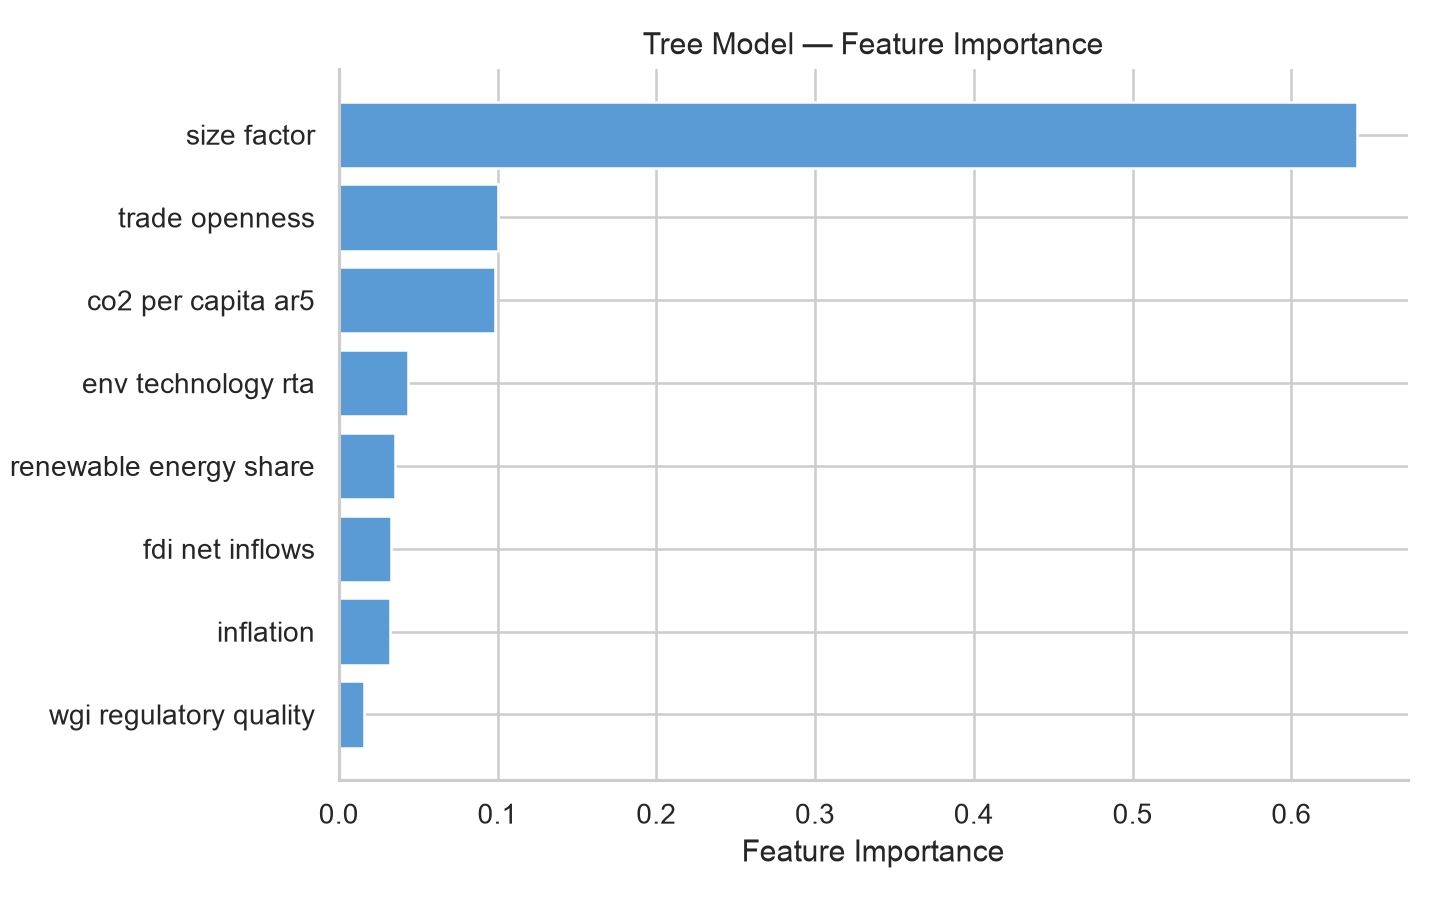

,feature,importance
0,size_factor_lag1_3_mean,0.6411
1,trade_openness_lag1_3_mean,0.1004
2,co2_per_capita_ar5_lag1_3_mean,0.0985
3,env_technology_rta_lag1_3_mean,0.0437
4,renewable_energy_share_lag1_3_mean,0.0352
5,fdi_net_inflows_lag1_3_mean,0.0328
6,inflation_lag1_3_mean,0.0325
7,wgi_regulatory_quality_lag1_3_mean,0.0158


In [8]:
# Feature-importance figure is produced by run_tree_modeling() -> make_tree_model_figures().
# The notebook only DISPLAYS the pre-generated PNG (no inline plotting logic).
if TREE_IMPORTANCE_OUTPUT.exists():
    show_tree_figure("tree_model_feature_importance")
    display(pd.read_csv(TREE_IMPORTANCE_OUTPUT)[["feature", "importance"]].round(4))
else:
    print("Not yet generated. Run `python 3_models/scripts/run_modeling.py --both`.")


## 7. Figures

Generated figures are in `4_analysis/figures/tree_modeling/`.

In [9]:
if TREE_FIGURE_INDEX_OUTPUT.exists():
    df = pd.read_csv(TREE_FIGURE_INDEX_OUTPUT)
    for _, row in df.iterrows():
        png = TREE_FIGURES_DIR / (row["figure"] + ".png")
        if png.exists():
            print(f"📊 {row['figure']}: {png}")
else:
    print("Not yet generated.")

## 8. Comparison: Linear vs Tree

Load linear model results for side-by-side comparison.

In [10]:
LINEAR_TEST = ROOT / "3_models" / "outputs" / "linear_model_test_metrics.csv"
LINEAR_HISTORY = ROOT / "3_models" / "outputs" / "linear_model_historical_baseline_delta_summary.csv"

if LINEAR_TEST.exists() and TREE_TEST_METRICS_OUTPUT.exists():
    linear = pd.read_csv(LINEAR_TEST)
    tree = pd.read_csv(TREE_TEST_METRICS_OUTPUT)
    
    print(f"{'Metric':<25} {'Linear (ElasticNet)':>20} {'Tree (best)':>20}")
    print("-" * 65)
    for col in ["mae", "rmse", "oos_r2_vs_train_mean", "spearman"]:
        lv = linear.iloc[0][col]
        tv = tree.iloc[0][col]
        better = "←" if float(tv) < float(lv) else ""
        print(f"{col:<25} {float(lv):>20.4f} {float(tv):>20.4f} {better}")
else:
    print("Need both linear and tree results to compare.")
    print(f"Linear exists: {LINEAR_TEST.exists()}")
    print(f"Tree exists: {TREE_TEST_METRICS_OUTPUT.exists()}")

Metric                     Linear (ElasticNet)          Tree (best)
-----------------------------------------------------------------
mae                                     1.0635               0.4648 ←
rmse                                    2.4040               1.8934 ←
oos_r2_vs_train_mean                    0.6623               0.7905 
spearman                                0.8459               0.8314 ←


## 9. Mechanism submodels — same-sample nested test (Linear vs Tree) ⭐

> **Key new finding.** On the *same* country-year rows, do the submodel predictors
> (RISE/high-tech exports, R&D/co-invention, EPS policy) improve accuracy over the
> 9 main controls? `Δ test MAE < 0` means they help.
>
> - **Linear** says *no* (Δ > 0): the extra predictors do not help a straight-line model.
> - **Tree** says *yes* (Δ < 0): the predictors carry **nonlinear** signal that RF/XGBoost can use.
>
> This is the headline result of adding submodels to the tree pipeline (paper Fig. 3).

In [11]:
# Same-sample nested comparison: main controls vs main + submodel predictors.
# Delta < 0 means the submodel predictors help. Read + display only (no inline plotting).
# Polished paper figure: 4_analysis/figures/paper/fig3_nested_incremental_value.png
LINEAR_NESTED = ROOT / "3_models" / "outputs" / "linear_model_nested_comparison.csv"
key = "delta_test_mae_augmented_minus_baseline"
labels = {"suba": "SubA (RISE, high-tech)", "subb": "SubB (R&D, co-invention)", "subc": "SubC (EPS policy)"}

if LINEAR_NESTED.exists() and TREE_NESTED_COMPARISON_OUTPUT.exists():
    lin = pd.read_csv(LINEAR_NESTED).set_index("comparison_group")
    tre = pd.read_csv(TREE_NESTED_COMPARISON_OUTPUT).set_index("comparison_group")
    groups = [g for g in ["suba", "subb", "subc"] if g in tre.index]
    comp = pd.DataFrame({
        "submodel": [labels.get(g, g) for g in groups],
        "rows": [int(tre.loc[g, "rows"]) for g in groups],
        "linear_delta_mae": [round(float(lin.loc[g, key]), 3) for g in groups],
        "tree_delta_mae": [round(float(tre.loc[g, key]), 3) for g in groups],
        "linear_helps": [bool(lin.loc[g, key] < 0) for g in groups],
        "tree_helps": [bool(tre.loc[g, key] < 0) for g in groups],
    })
    display(comp)
else:
    print("Run `python 3_models/scripts/run_modeling.py --both` first.")


,submodel,rows,linear_delta_mae,tree_delta_mae,linear_helps,tree_helps
0,"SubA (RISE, high-tech)",1012,0.000,-0.032,False,True
1,"SubB (R&D, co-invention)",2190,0.013,0.047,False,False
2,SubC (EPS policy),918,0.099,0.031,False,False


## 10. Robustness — per-million target & lag1 (t-1) timing (Tree)

> Does the *"cannot beat persistence"* conclusion survive changing the **target**
> (per-million) or the **lag** (t-1 vs 3-year mean)? `beats_best_historical_baseline`
> should be `False` everywhere, and lag1 vs lag1_3_mean should be almost equal.

In [12]:
if TREE_ROBUSTNESS_SUMMARY_OUTPUT.exists():
    rb = pd.read_csv(TREE_ROBUSTNESS_SUMMARY_OUTPUT)
    cols = ["robustness_id", "target_column", "lag_suffix", "best_model",
            "test_mae", "best_historical_baseline_mae",
            "delta_test_mae_selected_minus_best_history", "beats_best_historical_baseline"]
    display(rb[cols].round(3))
    print("\nReading guide:")
    print("- beats_best_historical_baseline = False everywhere -> conclusion holds for both targets.")
    print("- lag1 vs lag1_3_mean differ only marginally -> the lag choice does not drive results.")
else:
    print("Not yet generated. Run `python 3_models/scripts/run_modeling.py --both`.")

,robustness_id,target_column,lag_suffix,best_model,test_mae,best_historical_baseline_mae,delta_test_mae_selected_minus_best_history,beats_best_historical_baseline
0,robust_main_share_lag1,env_patent_share_inventions,lag1,rf_n200,0.536,0.312,0.224,False
1,robust_main_share_lag1_3_mean,env_patent_share_inventions,lag1_3_mean,xgb_n500_d6,0.465,0.312,0.153,False
2,robust_main_per_million_lag1,env_patents_per_million,lag1,rf_n500,3.846,2.573,1.273,False
3,robust_main_per_million_lag1_3_mean,env_patents_per_million,lag1_3_mean,rf_n500,3.463,2.573,0.890,False



Reading guide:
- beats_best_historical_baseline = False everywhere -> conclusion holds for both targets.
- lag1 vs lag1_3_mean differ only marginally -> the lag choice does not drive results.


## 11. Model family comparison — Linear vs RF vs XGBoost (all v2 panels, both lags)

> Generated by `3_models/scripts/model_family_comparison.py`. It selects the best model **within each family** on each panel x lag, so Linear / RandomForest / XGBoost are directly comparable on identical splits, each vs its own prediction-safe persistence baseline. This replaces the earlier table that mixed RF and XGB across panels.

Linear  RandomForest  XGBoost  Persistence
panel_id lag_suffix                                             
main     lag1          1.055         0.536    0.484        0.312
         lag1_3_mean   1.064         0.521    0.465        0.312
suba     lag1          1.753         1.386    1.668        0.283
         lag1_3_mean   1.753         1.446    1.682        0.283
subb     lag1          1.615         0.764    0.897        0.345
         lag1_3_mean   1.616         0.848    0.836        0.345
subc     lag1          3.384         3.981    3.999        0.468
         lag1_3_mean   3.395         3.993    3.586        0.468

Any family beats its persistence baseline? False


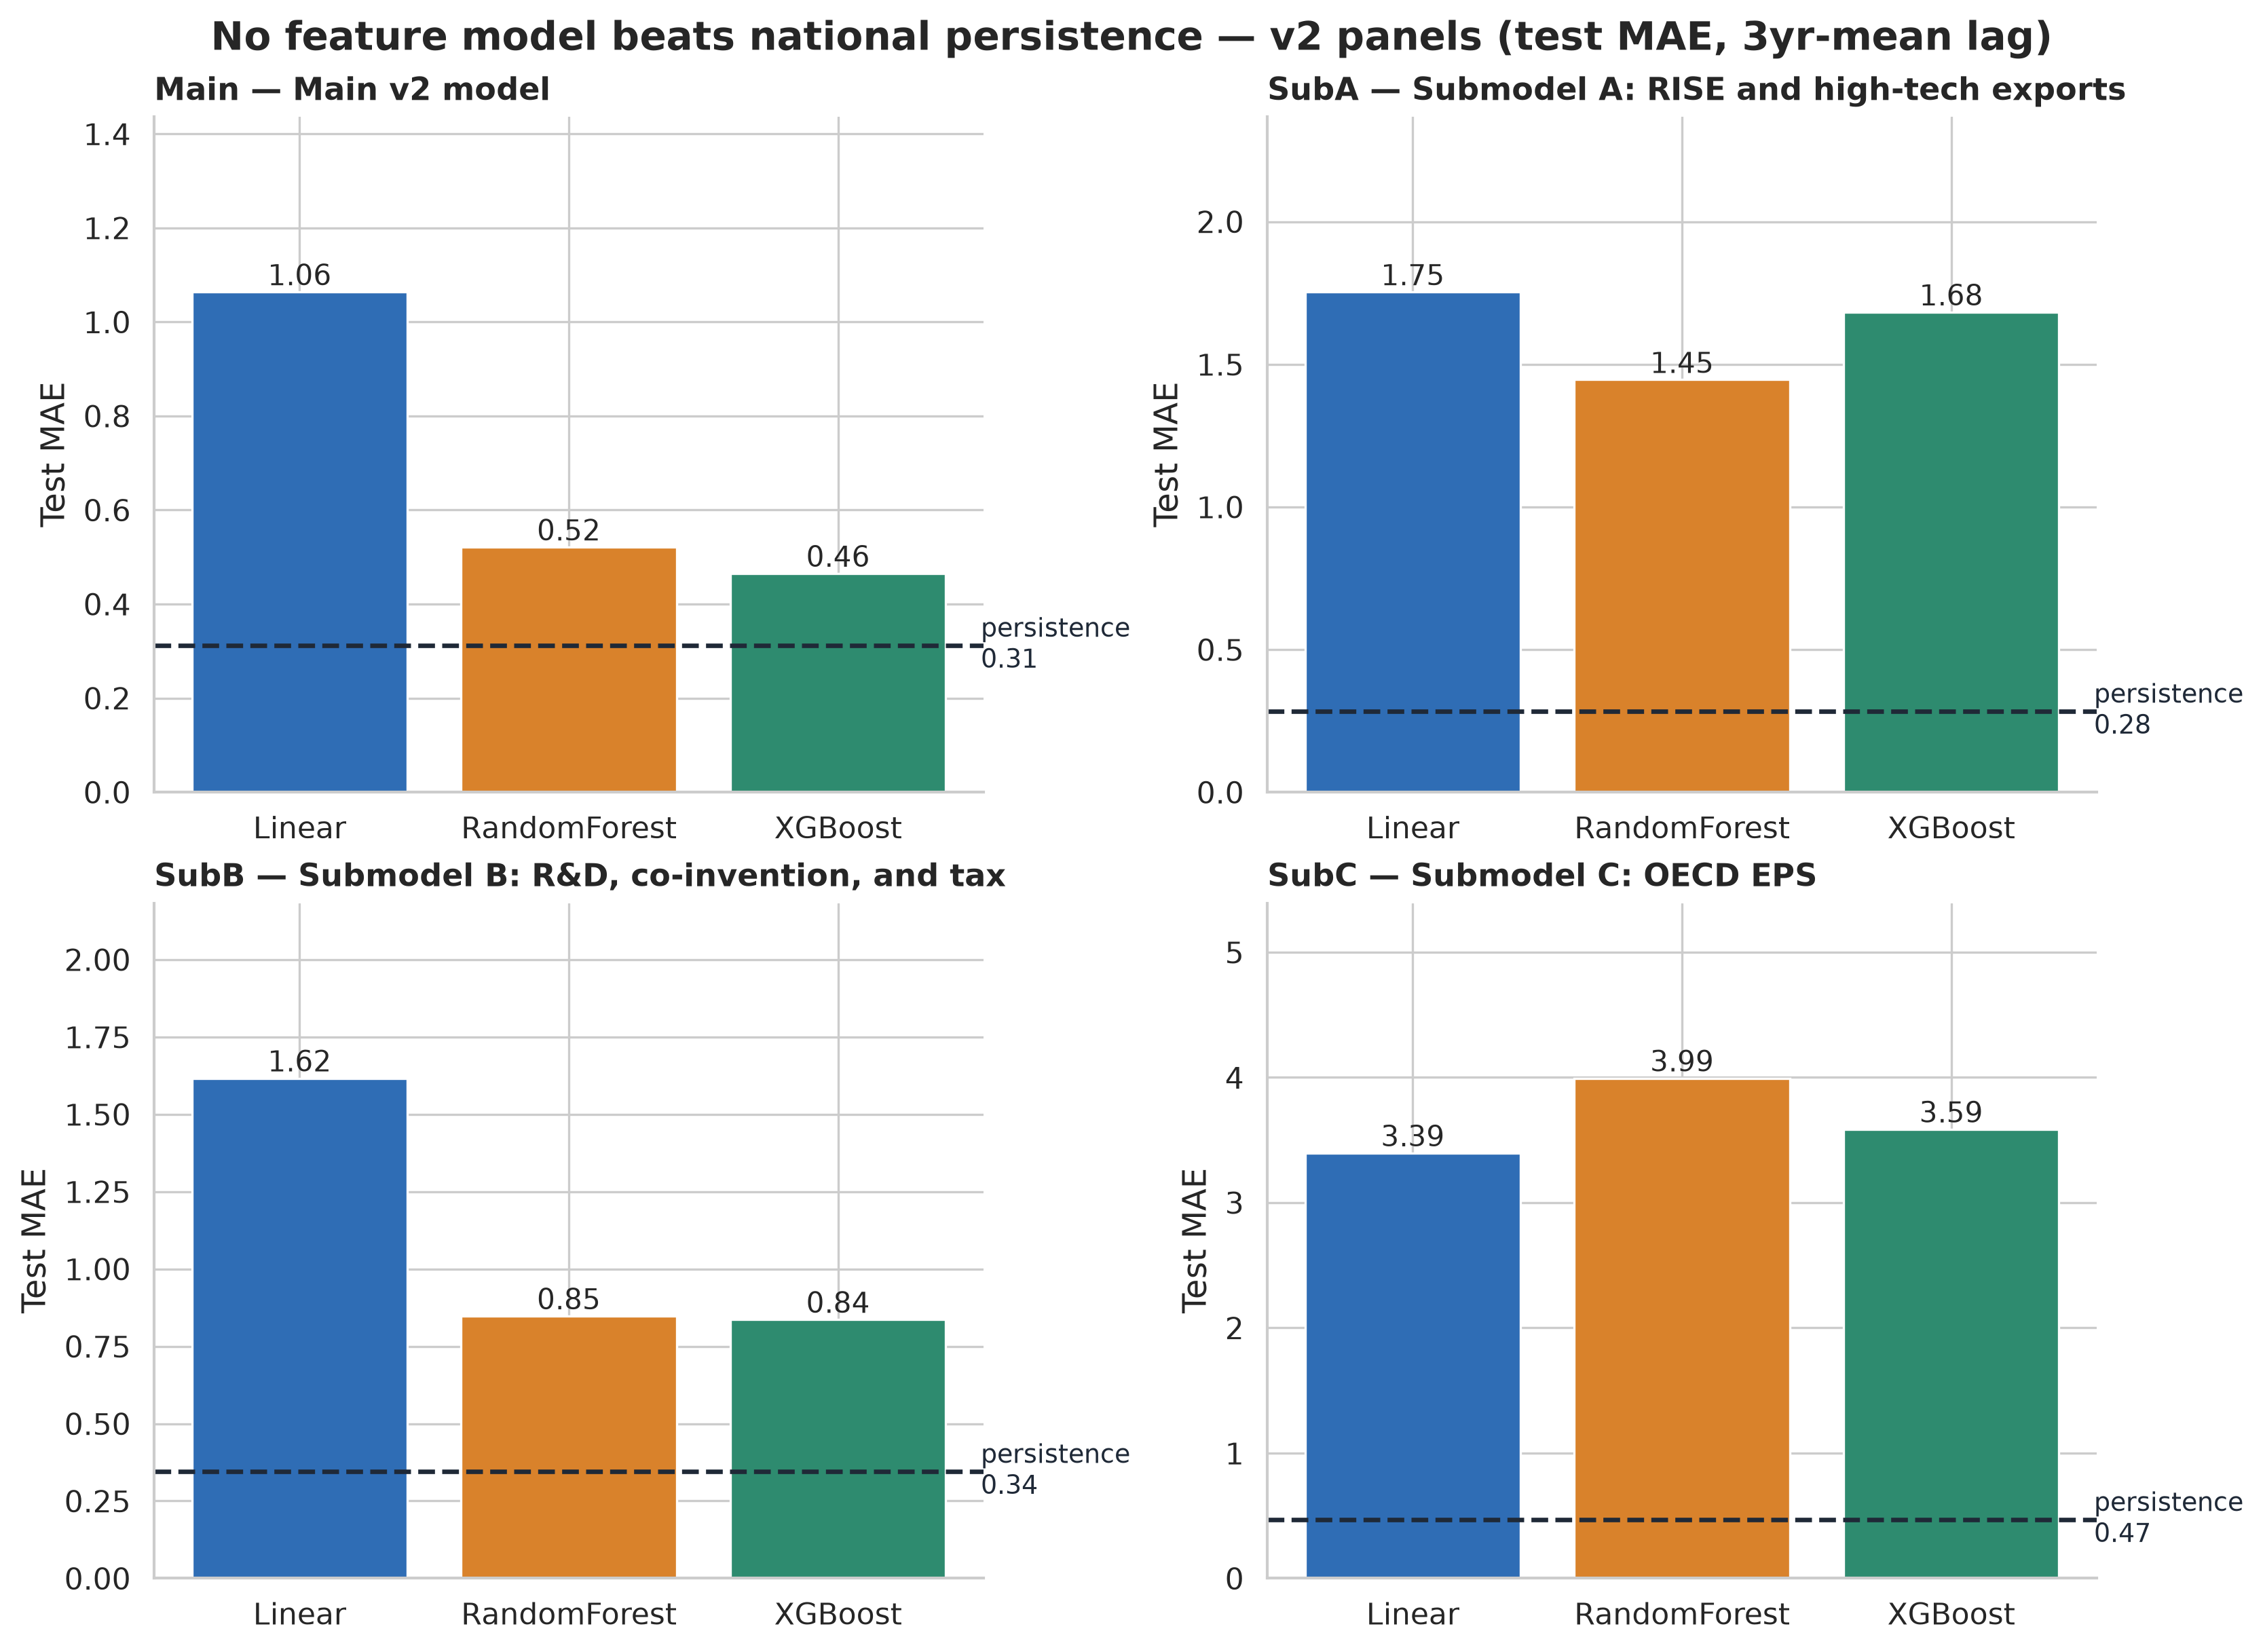

In [13]:
FAMILY_CMP = ROOT / "3_models" / "outputs" / "model_family_comparison.csv"
OVERVIEW_FIG = ROOT / "4_analysis" / "figures" / "paper" / "fig11_model_family_overview.png"
if FAMILY_CMP.exists():
    fam = pd.read_csv(FAMILY_CMP)
    pivot = fam.pivot_table(index=["panel_id", "lag_suffix"], columns="family", values="test_mae")
    base = fam.groupby(["panel_id", "lag_suffix"])["persistence_baseline_mae"].first().rename("Persistence")
    display(pivot.join(base).round(3))
    print("Any family beats its persistence baseline?", bool(fam["beats_baseline"].any()))
    if OVERVIEW_FIG.exists():
        display(Image(filename=str(OVERVIEW_FIG)))
else:
    print("Run: python 3_models/scripts/model_family_comparison.py")
